# Python Fundamentals for Data Analytics: Iris Dataset

This notebook demonstrates foundational Python data analytics skills using the **Iris** dataset. It covers pandas dataframe manipulation, NumPy processing, exploratory data analysis (EDA), Matplotlib visualization, filtering, grouping, merging, reshaping, reusable functions, loops, and conditionals.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

pd.set_option('display.max_columns', None)

## 1. Load the Dataset with pandas

In [2]:
# Load the built-in Iris dataset, then place it into a pandas DataFrame.
iris = load_iris()

feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
df = pd.DataFrame(iris.data, columns=feature_names)
df['species'] = [iris.target_names[i] for i in iris.target]

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 2. Exploratory Data Analysis (EDA)

In [3]:
print("Data types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print("\nDescriptive statistics:")
df.describe()

Data types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

Missing values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Descriptive statistics:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [4]:
# Check how many observations belong to each species.
species_counts = df['species'].value_counts().sort_index()
species_counts

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

## 3. Reusable Cleaning and Feature-Engineering Function

In [5]:
def prepare_iris(data):
    """Clean numeric columns and create derived features."""
    cleaned = data.copy()
    numeric_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

    # Loop through numeric columns and use a conditional to handle missing values.
    for col in numeric_cols:
        cleaned[col] = pd.to_numeric(cleaned[col], errors='coerce')
        if cleaned[col].isna().any():
            cleaned[col] = cleaned[col].fillna(cleaned[col].median())

    # NumPy is used to calculate a ratio safely.
    cleaned['petal_to_sepal_ratio'] = np.where(
        cleaned['sepal_length'] != 0,
        cleaned['petal_length'] / cleaned['sepal_length'],
        np.nan
    )

    return cleaned

clean_df = prepare_iris(df)
clean_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,petal_to_sepal_ratio
0,5.1,3.5,1.4,0.2,setosa,0.274510
1,4.9,3.0,1.4,0.2,setosa,0.285714
2,4.7,3.2,1.3,0.2,setosa,0.276596
3,4.6,3.1,1.5,0.2,setosa,0.326087
4,5.0,3.6,1.4,0.2,setosa,0.280000


## 4. Custom Function with Conditionals

In [6]:
def classify_petal(length):
    if length < 2.0:
        return 'short'
    elif length < 5.0:
        return 'medium'
    else:
        return 'long'

clean_df['petal_size'] = clean_df['petal_length'].apply(classify_petal)
clean_df[['petal_length', 'petal_size']].head(10)

,petal_length,petal_size
0,1.4,short
1,1.4,short
2,1.3,short
3,1.5,short
4,1.4,short
5,1.7,short
6,1.4,short
7,1.5,short
8,1.4,short
9,1.5,short


## 5. Data Manipulation: Filter

In [7]:
# Filter flowers with petal length greater than 4.5 cm.
long_petal_df = clean_df[clean_df['petal_length'] > 4.5]

print(f"Rows with petal_length > 4.5 cm: {len(long_petal_df)}")
long_petal_df['species'].value_counts()

Rows with petal_length > 4.5 cm: 63


species
virginica     49
versicolor    14
Name: count, dtype: int64

## 6. Data Manipulation: Group and Aggregate

In [8]:
species_summary = (
    clean_df.groupby('species')
    .agg(
        mean_sepal_length=('sepal_length', 'mean'),
        mean_sepal_width=('sepal_width', 'mean'),
        mean_petal_length=('petal_length', 'mean'),
        mean_petal_width=('petal_width', 'mean')
    )
    .round(3)
    .reset_index()
)

species_summary

,species,mean_sepal_length,mean_sepal_width,mean_petal_length,mean_petal_width
0,setosa,5.006,3.428,1.462,0.246
1,versicolor,5.936,2.770,4.260,1.326
2,virginica,6.588,2.974,5.552,2.026


## 7. Data Manipulation: Merge

In [9]:
# Build a second table containing sample counts, then merge it with the summary table.
count_table = (
    clean_df.groupby('species')
    .size()
    .reset_index(name='sample_count')
)

merged_summary = pd.merge(species_summary, count_table, on='species', how='left')
merged_summary

,species,mean_sepal_length,mean_sepal_width,mean_petal_length,mean_petal_width,sample_count
0,setosa,5.006,3.428,1.462,0.246,50
1,versicolor,5.936,2.770,4.260,1.326,50
2,virginica,6.588,2.974,5.552,2.026,50


## 8. Data Manipulation: Reshape with a Pivot Table

In [10]:
pivot_table = clean_df.pivot_table(
    values='sepal_length',
    index='species',
    columns='petal_size',
    aggfunc='mean'
).round(3)

pivot_table

petal_size,long,medium,short
species,,,
setosa,NaN,NaN,5.006
versicolor,6.350,5.919,NaN
virginica,6.689,5.850,NaN


## 9. Matplotlib Plot 1: Sepal Length Distribution

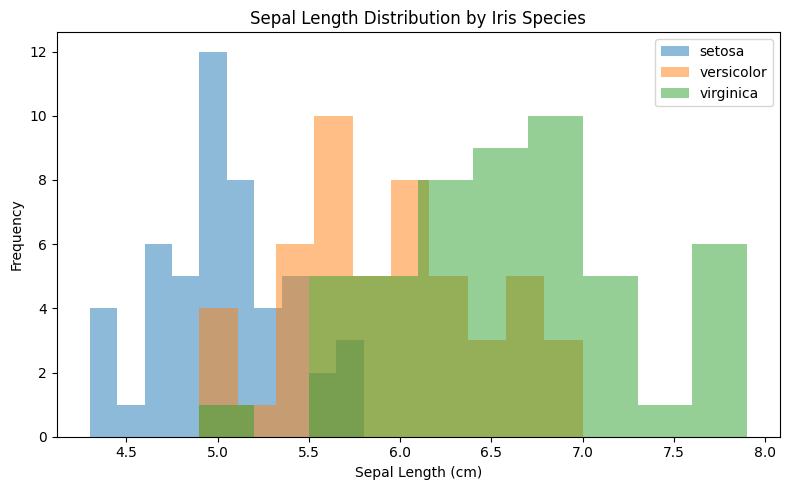

In [11]:
plt.figure(figsize=(8, 5))
for species in clean_df['species'].unique():
    values = clean_df.loc[clean_df['species'] == species, 'sepal_length']
    plt.hist(values, bins=10, alpha=0.5, label=species)

plt.xlabel('Sepal Length (cm)')
plt.ylabel('Frequency')
plt.title('Sepal Length Distribution by Iris Species')
plt.legend()
plt.tight_layout()
plt.show()

## 10. Matplotlib Plot 2: Mean Petal Length by Species

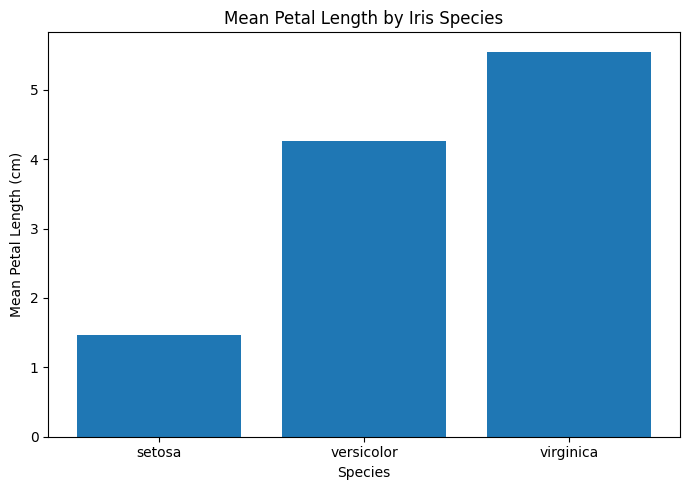

In [12]:
mean_petal = clean_df.groupby('species')['petal_length'].mean().sort_values()

plt.figure(figsize=(7, 5))
plt.bar(mean_petal.index, mean_petal.values)
plt.xlabel('Species')
plt.ylabel('Mean Petal Length (cm)')
plt.title('Mean Petal Length by Iris Species')
plt.tight_layout()
plt.show()

## 11. Additional Observation: Correlation

In [13]:
correlation_matrix = clean_df[
    ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
].corr().round(3)

correlation_matrix

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000,-0.118,0.872,0.818
sepal_width,-0.118,1.000,-0.428,-0.366
petal_length,0.872,-0.428,1.000,0.963
petal_width,0.818,-0.366,0.963,1.000


## Key Takeaways

- The dataset contains 150 observations and 4 numeric flower measurements, with 50 samples for each of the three species.
- No missing values were found.
- Petal measurements provide strong separation among the species: setosa has much shorter petals than versicolor and virginica.
- Filtering, grouping, merging, and pivoting provide different views of the same underlying data.
- Reusable functions, loops, conditionals, and NumPy operations make the analysis easier to automate and extend.